# Lab 3 — Semantic Search

Run this notebook top to bottom as you build out `embeddings.py` and `search.py` in this same folder. See `Lab3_Instructions.md` for what belongs in each step.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the corpus, example queries, and visualization are yours to write.

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from embeddings import _get_embedding_api, _get_embedding_offline
from search import load_documents, build_embedding_matrix, search

## Step 1-2: Load your corpus and fetch embeddings

In [8]:
# TODO: load_documents("documents.json") and build_embedding_matrix(documents)
# Start in offline mode (the default) while you're building - switch to the real
# API once your pipeline works end to end.
documents=load_documents('documents.json')
embedding_matrix=build_embedding_matrix(documents)
print(f'Loaded {len(documents)} document across {len(set(d['topic'] for d in documents))} topics.')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Loaded 35 document across 5 topics.
Embedding matrix shape: (35, 64)


## Step 3: Run a few example search queries

In [9]:
# TODO: call search(query, embedding_matrix, documents, top_k=3) with at least two
# different queries and print the results
example_queries=[
    'What is the capital of France',
    'How do neural networks work?'
]

for q in example_queries:
    print(f"Query: {q!r}")

    for r in search(q, embedding_matrix, documents, top_k=3):
        print(f"[{r['score']: .3f}] ({r['topic']}) {r['text'][:70]}...")
    print()

Query: 'What is the capital of France'
[ 0.663] (geography) Paris is the capital and most populous city of France, located along t...
[ 0.639] (technology) Open-source software is released with a license granting users the rig...
[ 0.500] (science) Plate tectonics describes how the Earth's outer shell is divided into ...

Query: 'How do neural networks work?'
[ 0.439] (history) The Industrial Revolution, beginning in the late 18th century, transfo...
[ 0.351] (technology) Cloud computing allows users to access computing resources such as ser...
[ 0.316] (science) Plate tectonics describes how the Earth's outer shell is divided into ...



## Step 4: Visualize the embedding space with PCA

In [10]:
# TODO: reuse your Lab 2 PCA-via-SVD function (extended to 2 components) to project
# the embedding matrix down to 2D, then scatter-plot it colored by topic
def pca_svd(X, n_components=2):
    X_centered=X - X.mean(axis=0)
    U, S, Vt=np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:n_components].T

In [11]:
coords_2d=pca_svd(embedding_matrix, n_components=2)

topics=[d['topic'] for d in documents]
unique_topics=sorted(set(topics))
colors=plt.cm.tab10(np.linspace(0, 1, len(unique_topics)))

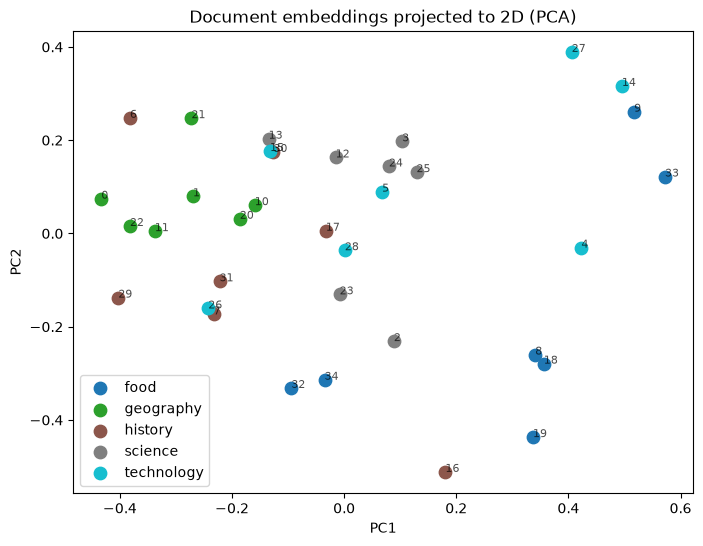

In [ ]:
plt.figure(figsize=(8, 6))
for topic, color in zip(unique_topics, colors):
    idxs=[i for i,t in enumerate(topics) if t==topic]
    plt.scatter(coords_2d[idxs, 0], coords_2d[idxs, 1], label=topic, color=color, s=80)

# Label every point with its document id, so you can trace a point back
# to documents.json when eyeballing the plot
for i,doc in enumerate(documents):
    plt.annotate(str(doc['id']), (coords_2d[i, 0], coords_2d[i, 1]), fontsize=8, alpha=0.7)

# Show the topic -> color legend built from the `label=topic` kwargs above
plt.legend()

# Title and axis labels — required by the rubric ("axis labels and a title", 10%)
plt.title('Document embeddings projected to 2D (PCA)')
plt.xlabel('PC1') # first principal component (direction of greatest variance)
plt.ylabel('PC2')  # second principal component (direction of second-greatest variance)

# Save BEFORE show() — order matters
plt.savefig('embedding_space.png', dpi=150, bbox_inches='tight')

plt.show()